# EX - Mall Customers klasterdamine

See mall annab sulle peatükid ja kohad, kuhu oma analüüs ning järeldused lisada. Täida koodiplokid ja lisa lühikesed selgitused, miks valisid need sammud. Fail `mall_customers.csv` peab asuma sama kausta sees.

## 1. Andmete laadimine

Impordi vajalikud teegid, loe `mall_customers.csv` DataFrame'i ning näita mõõtmeid ja esimesi ridu, et kinnitada, et fail on korras.

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/Colab Notebooks/mall_customers.csv'
else:
    path = 'mall_customers.csv'

df = None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loeme andmed csv failist ja moodustame andmetest DF'i

In [62]:
data = pd.read_csv(path)
df = pd.DataFrame(data)

In [63]:
# Kontroll
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Väidetavalt on andmestik korrastatud ja puhastatud, kuid teeme siiski kiire ckeck'i veendumaks, et puuduvaid väärtusi pole

In [64]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Laetud andmete uurimine

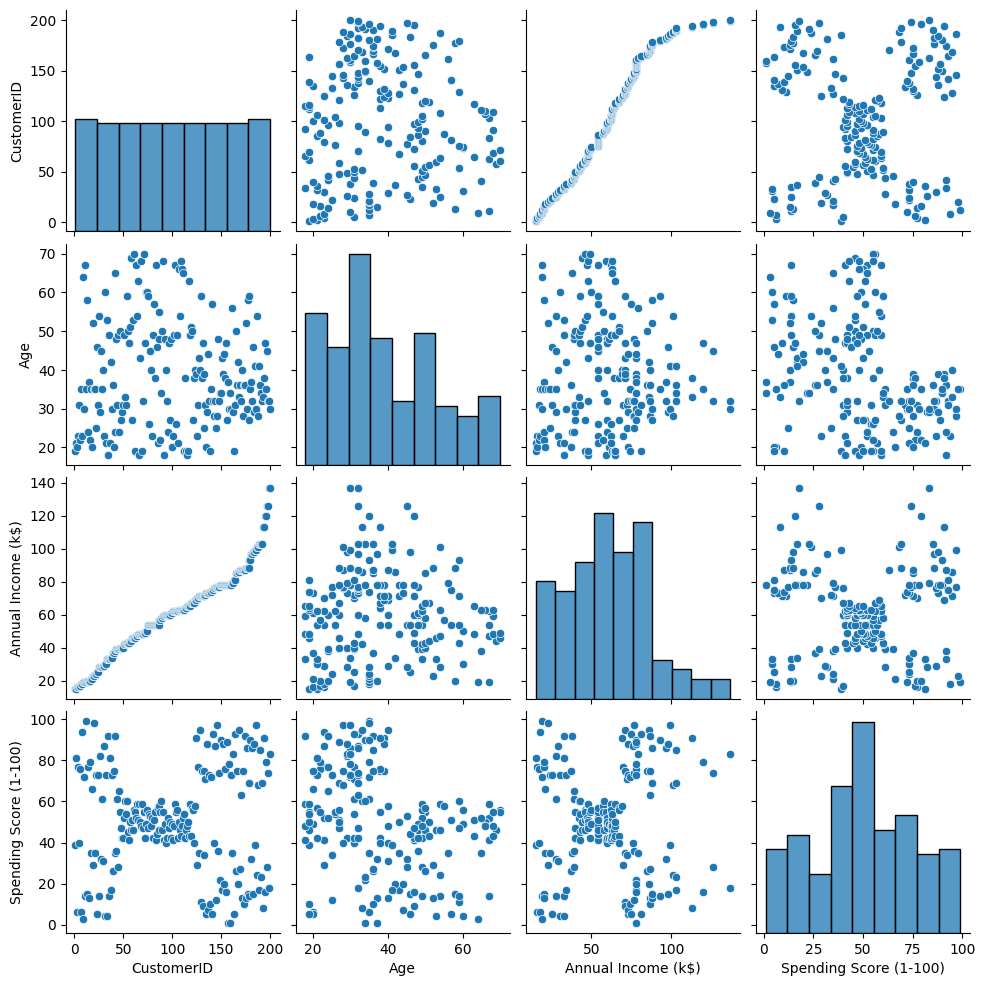

In [65]:
# Vaatame andmeid tunnuspaaride kaupa
sns.pairplot(df)

## 2. Density Based Spacial Clustering Of Application With Noise

Treeni DBSCAN mudel.

In [66]:
# Eemaldame CustomerID andmestikust
data = data.drop(['CustomerID'] , axis=1)

In [67]:
# Võtame kõik read, kuid ainult tulba 2 ja 3 (Annual Income ja Spending Score)
x = data.iloc[:,[2,3]]

In [68]:
# kontroll
print(type(x))
print(x[:10])

<class 'pandas.core.frame.DataFrame'>
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40
5                  17                      76
6                  18                       6
7                  18                      94
8                  19                       3
9                  19                      72


In [69]:
# Vaatame esimesi ridu, transponeerime
data.head().T

,0,1,2,3,4
Gender,Male,Male,Female,Female,Female
Age,19,21,20,23,31
Annual Income (k$),15,15,16,16,17
Spending Score (1-100),39,81,6,77,40


In [70]:
# Muundame numpy massiiviks
x = x.values

In [71]:
# kontroll
print(type(x))
print(x[:10])

<class 'numpy.ndarray'>
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]
 [17 76]
 [18  6]
 [18 94]
 [19  3]
 [19 72]]


In [72]:
# koostame DBSCAN mudeli
# eps - epsilon, maks kaugus, mille piires loetakse naabriks; min_samples - miinimum kogus naabreid, mis moodustab klastri
db = DBSCAN(eps=9 , min_samples=3 , metric='euclidean')
# kohandame mudeli
model = db.fit(x)

In [73]:
# grupi tunnused
label = model.labels_
# vaatame üle
label

array([ 0,  1,  2,  1,  0,  1,  2,  3,  2,  1,  2,  3,  2,  1,  2,  1,  0,
        1,  0,  3,  0,  1,  2,  1,  2,  1,  0,  1,  0,  1,  2,  1,  2,  1,
        2,  1,  2,  1,  4,  1,  4,  1,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  5,  4,  5,  4,  5,  6,  5,  6,  5,  4,  5,  6,  5,
        6,  5,  6,  5,  6,  5,  4,  5,  6,  5,  4,  5,  6,  5,  6,  5,  6,
        5,  6,  5,  6,  5,  6,  5,  4,  5,  6,  5,  6,  5,  6,  5,  6,  5,
        6,  5,  6,  5,  6,  5,  6,  5,  6,  5,  6,  5,  6,  5,  6, -1,  6,
       -1,  6,  5,  6, -1, -1, -1, -1, -1, -1, -1, -1, -1])

-1 tähendab siin erindeid või müra

In [74]:
# arvutame klastrite arvu
n_clusters = len(set(label))-(1 if -1 in label else 0)
print('Number of clusters:' , n_clusters)

Number of clusters: 7


In [75]:
y_means = db.fit_predict(x)
# tulemuste kontroll
y_means

array([ 0,  1,  2,  1,  0,  1,  2,  3,  2,  1,  2,  3,  2,  1,  2,  1,  0,
        1,  0,  3,  0,  1,  2,  1,  2,  1,  0,  1,  0,  1,  2,  1,  2,  1,
        2,  1,  2,  1,  4,  1,  4,  1,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  5,  4,  5,  4,  5,  6,  5,  6,  5,  4,  5,  6,  5,
        6,  5,  6,  5,  6,  5,  4,  5,  6,  5,  4,  5,  6,  5,  6,  5,  6,
        5,  6,  5,  6,  5,  6,  5,  4,  5,  6,  5,  6,  5,  6,  5,  6,  5,
        6,  5,  6,  5,  6,  5,  6,  5,  6,  5,  6,  5,  6,  5,  6, -1,  6,
       -1,  6,  5,  6, -1, -1, -1, -1, -1, -1, -1, -1, -1])

Siin -> x[[y_means == i , 0]] and x[y_means == i , 1] , valime i'nda klastri punktide x ja y koordinaadid

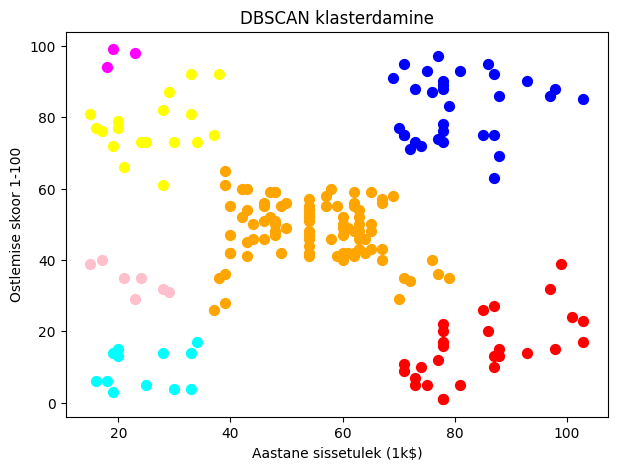

In [76]:
# Kuvame klastrid
plt.figure(figsize=(7,5))
plt.scatter(x[y_means == 0 , 0],x[y_means == 0 , 1] , s = 50 , c = 'pink')
plt.scatter(x[y_means == 1 , 0],x[y_means == 1 , 1] , s = 50 , c = 'yellow')
plt.scatter(x[y_means == 2 , 0],x[y_means == 2 , 1] , s = 50 , c = 'cyan')
plt.scatter(x[y_means == 3 , 0],x[y_means == 3 , 1] , s = 50 , c = 'magenta')
plt.scatter(x[y_means == 4 , 0],x[y_means == 4 , 1] , s = 50 , c = 'orange')
plt.scatter(x[y_means == 5 , 0],x[y_means == 5 , 1] , s = 50 , c = 'blue')
plt.scatter(x[y_means == 6 , 0],x[y_means == 6 , 1] , s = 50 , c = 'red')
plt.scatter(x[y_means == 7 , 0],x[y_means == 7 , 1] , s = 50 , c = 'black')
plt.scatter(x[y_means == 8 , 0],x[y_means == 8 , 1] , s = 50 , c = 'violet')
plt.title('DBSCAN klasterdamine')
plt.xlabel('Aastane sissetulek (1k$)')
plt.ylabel('Ostlemise skoor 1-100')
plt.show()